<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_ninth_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv("creditcard.csv")


In [2]:
data.head()
data.info()
data.describe()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9965 entries, 0 to 9964
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    9965 non-null   int64  
 1   V1      9965 non-null   float64
 2   V2      9965 non-null   float64
 3   V3      9964 non-null   float64
 4   V4      9964 non-null   float64
 5   V5      9964 non-null   float64
 6   V6      9964 non-null   float64
 7   V7      9964 non-null   float64
 8   V8      9964 non-null   float64
 9   V9      9964 non-null   float64
 10  V10     9964 non-null   float64
 11  V11     9964 non-null   float64
 12  V12     9964 non-null   float64
 13  V13     9964 non-null   float64
 14  V14     9964 non-null   float64
 15  V15     9964 non-null   float64
 16  V16     9964 non-null   float64
 17  V17     9964 non-null   float64
 18  V18     9964 non-null   float64
 19  V19     9964 non-null   float64
 20  V20     9964 non-null   float64
 21  V21     9964 non-null   float64
 22  

,0
Time,0
V1,0
V2,0
V3,1
V4,1
V5,1
V6,1
V7,1
V8,1
V9,1


In [3]:
# No missing values in this dataset, but check anyway
data = data.dropna()


In [4]:
data.groupby("Class")["Amount"].mean()


,Amount
Class,
0.0,62.919501
1.0,75.730526


In [5]:
highest = data.loc[data["Amount"].idxmax()]
lowest = data.loc[data["Amount"].idxmin()]

print("Highest:", highest["Amount"], "Class:", highest["Class"])
print("Lowest:", lowest["Amount"], "Class:", lowest["Class"])


Highest: 7712.43 Class: 0.0
Lowest: 0.0 Class: 0.0


/tmp/ipykernel_4046/3952088840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class", y="Amount", data=ranked, palette="viridis")


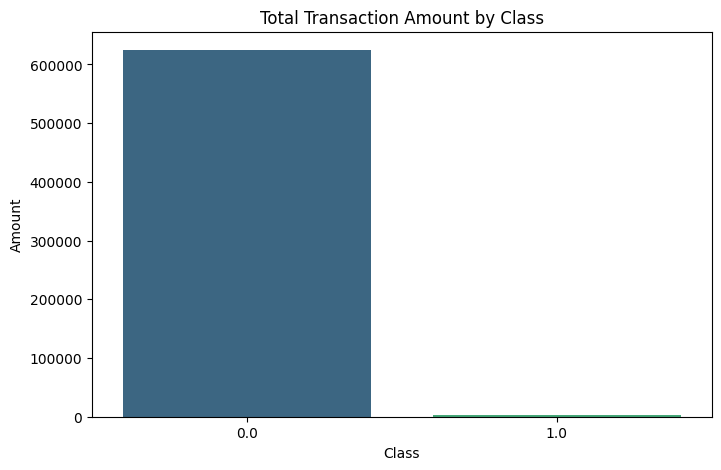

In [6]:
ranked = data.groupby("Class")["Amount"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Class", y="Amount", data=ranked, palette="viridis")
plt.title("Total Transaction Amount by Class")
plt.show()


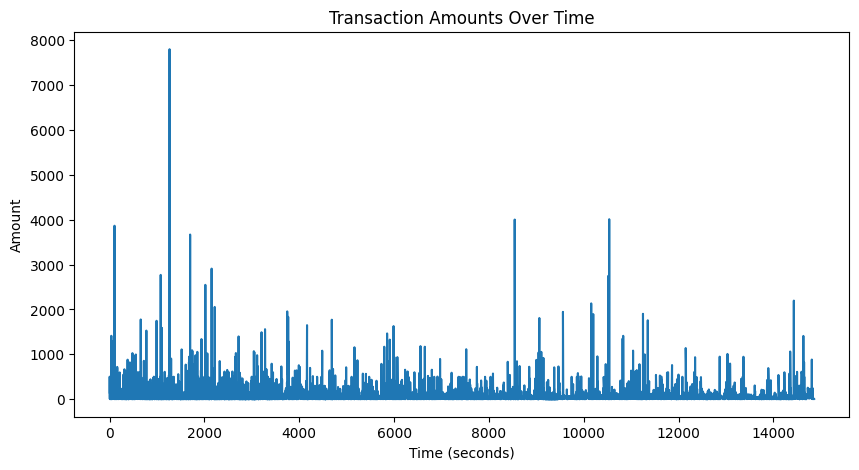

In [7]:
data.groupby("Time")["Amount"].sum().plot(kind="line", figsize=(10,5))
plt.title("Transaction Amounts Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Amount")
plt.show()


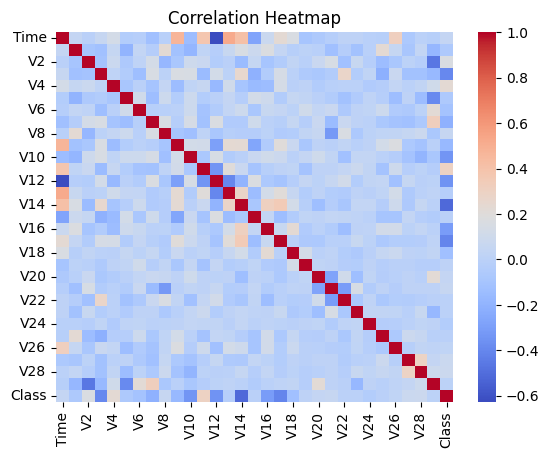

In [8]:
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
data.groupby(["Class"])["Amount"].describe()


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,9926.0,62.919501,184.041297,0.0,5.1725,15.95,51.0675,7712.43
1.0,38.0,75.730526,304.521215,0.0,1.0000,1.00,1.0000,1809.68


Fraudulent transactions are rare (less than 1% of the dataset) but show distinct patterns in transaction amounts and timing.
Insight: Fraud is highly imbalanced compared to normal transactions.
Recommendation: Use resampling or specialized algorithms to handle imbalance.


In [10]:
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9989964877069744
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1985
         1.0       1.00      0.75      0.86         8

    accuracy                           1.00      1993
   macro avg       1.00      0.88      0.93      1993
weighted avg       1.00      1.00      1.00      1993



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


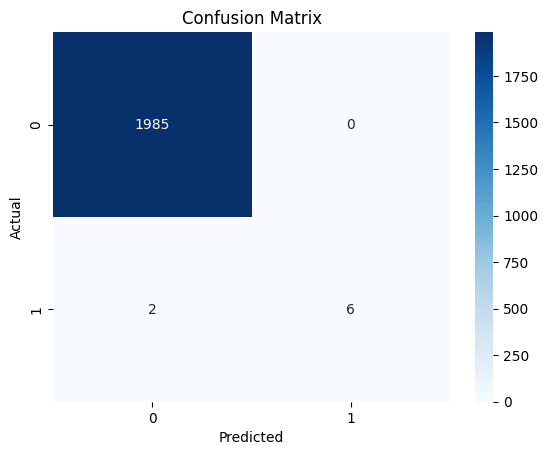

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


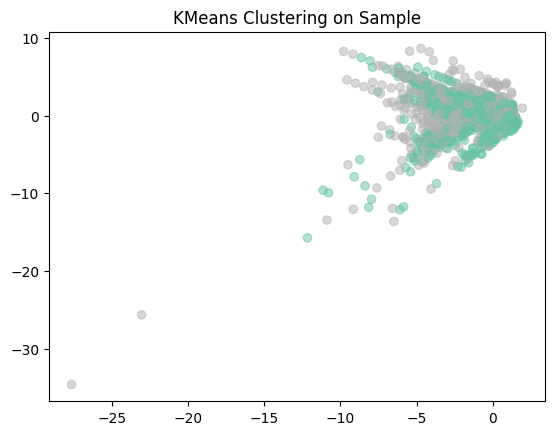

In [13]:
X_sample = data.sample(data.shape[0], random_state=42).drop("Class", axis=1)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_sample)

plt.scatter(X_sample["V1"], X_sample["V2"], c=clusters, cmap="Set2", alpha=0.5)
plt.title("KMeans Clustering on Sample")
plt.show()

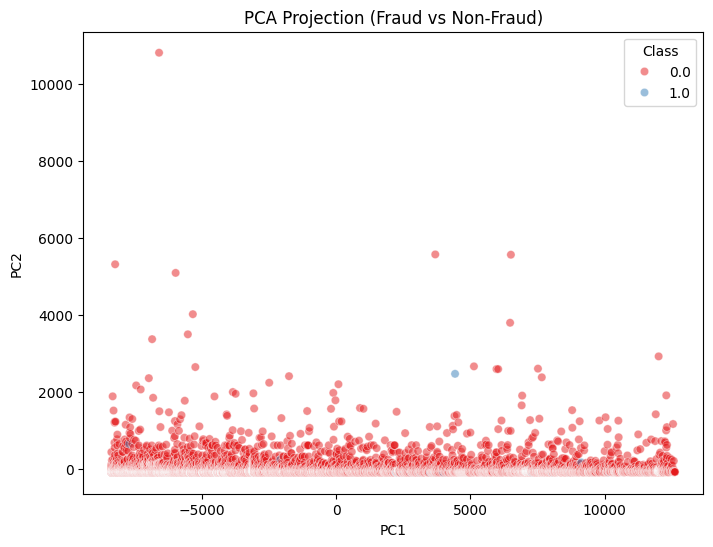

Explained variance ratio: [0.99828048 0.00171886]


In [15]:
X_num = data.drop("Class", axis=1)

pca = PCA(n_components=2)
pc = pca.fit_transform(X_num)

data["PC1"] = pc[:,0]
data["PC2"] = pc[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Class", data=data, palette="Set1", alpha=0.5)
plt.title("PCA Projection (Fraud vs Non-Fraud)")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

In [16]:
# Log-transform skewed features (Amount is highly skewed)
import numpy as np
data["LogAmount"] = np.log1p(data["Amount"])

# Transaction frequency per time window
data["Hour"] = (data["Time"] // 3600) % 24   # convert seconds to hours
data["Day"] = data["Time"] // (24*3600)      # convert seconds to days

# Ratio features
data["Amount_per_Time"] = data["Amount"] / (data["Time"] + 1)


In [18]:
# Rolling mean of transaction amounts (grouped by day)
daily_amounts = data.groupby("Day")["Amount"].transform("mean")
data["DailyMeanAmount"] = daily_amounts

# Z-score normalization for Amount
data["Amount_zscore"] = (data["Amount"] - data["Amount"].mean()) / data["Amount"].std()


In [19]:
# Example: interaction between anonymized features V1 and V2
data["V1_V2_interaction"] = data["V1"] * data["V2"]
